# Формула цифрового счастья
## Анализ эмоционального фона ВКонтакте с помощью ML и Deep Learning

Выполнили: Дарья Сечкина и Валерия Нам, ПАДИИ 2 курс  

### Структура ноутбука

| № | Раздел |
|---|--------|
| 1 | Постановка задачи |
| 2 | Загрузка и описание данных (2 датасета) |
| 3 | Разведочный анализ данных (EDA) |
| 4 | Предобработка текстов |
| 5 | Baseline: TF-IDF + Logistic Regression |
| 6 | TF-IDF + LinearSVC + кросс-валидация |
| 7 | Deep Learning: RuBERT (zero-shot inference) |
| 8 | Сравнение моделей: количественный и качественный анализ |
| 9 | Применение лучшей модели к постам ВКонтакте |
| 10 | Расчёт Индекса цифрового счастья |
| 11 | Сегментированный анализ и визуализация |
| 12 | Выводы и ограничения |

## 1. Постановка задачи

**Цель:** разработать метрику **Happiness Index** — количественную оценку цифрового благополучия пользователей ВКонтакте на основе открытого цифрового следа (тексты постов, паттерны активности, социальные связи) без прямого анкетирования.

**ML-задача:** трёхклассовая классификация тональности текста (`негативный / позитивный / нейтральный`) для оценки эмоционального фона пользовательского контента.

**Формула Индекса счастья:**

$$\text{Happiness_Index} = 0.30 \cdot S_{\text{network}} + 0.20 \cdot S_{\text{activity}} + 0.50 \cdot S_{\text{sentiment}}$$

| Компонент | Признак | Вес | Обоснование |
|-----------|---------|-----|-------------|
| $S_{\text{network}}$ | Кол-во друзей| 0.30 | Социальные связи коррелируют с субъективным благополучием
| $S_{\text{activity}}$ | Посты + репосты | 0.20 | Вовлечённость в платформу как показатель социальной активности |
| $S_{\text{sentiment}}$ | Доля позитивных постов | 0.50 | Ключевой показатель: эмоциональный фон контента (наибольший вес) |

При наличии токсичных/депрессивных сообществ применяется штрафной коэффициент ×0.85.  
Все компоненты нормированы в диапазоне [0, 1].

**Основная метрика оценки моделей:** weighted F1-score — учитывает баланс классов и применима к трёхклассовой задаче.

**Этический протокол:** данные собраны только из публичных профилей (is_closed: False); в итоговом датасете пользователи представлены обезличенными ID; личные сообщения и закрытые данные не запрашивались.

### Установка зависимостей

In [24]:
!pip install datasets transformers torch scikit-learn seaborn matplotlib pandas tqdm

## Импорты и конфигурация

In [25]:
import json
import re
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (f1_score, accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from datasets import load_dataset
from transformers import pipeline as hf_pipeline
import torch
sns.set_theme(style="whitegrid", palette="pastel")
RANDOM_STATE = 42
DEVICE = 0 if torch.cuda.is_available() else -1
TARGET_NAMES = ['Негативный', 'Позитивный', 'Нейтральный']
LABEL2NAME = {0: 'Негативный', 1: 'Позитивный', 2: 'Нейтральный'}
TOXIC_KEYWORDS = ['депрессия', 'грусть', 'боль', 'слезы', 'одиночество', 'апатия', 'ненависть', 'суицид', 'смерть', 'безысходность']
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()} | Device: {'GPU' if DEVICE == 0 else 'CPU'}")

PyTorch: 2.11.0+cu128
CUDA available: True | Device: GPU


## 2. Загрузка и описание данных

Проект использует **два датасета** из открытых источников:

| # | Датасет | Источник | Размер | Описание |
|---|---------|----------|--------|----------|
| 1 | `data.json` | VK API (собственный сбор) | ~230 профилей | Пользователи 18–35 лет, 7 городов РФ |
| 2 | `k1tub/sentiment_dataset` | [HuggingFace Datasets](https://huggingface.co/datasets/k1tub/sentiment_dataset) | 290 458 текстов | Русскоязычный корпус тональности |

### Датасет 1: Пользователи ВКонтакте (`data.json`)

Собран через VK API из публичных профилей (is_closed: False). Включает тексты постов, социальные метрики и данные об участии в сообществах.

In [26]:
with open('data.json', 'r', encoding='utf-8') as f:
    raw_data = json.load(f)
users_list = []
posts_list = []
for u in raw_data:
    age = u.get('age', 0)
    friends_num = u.get('friends_num', 0)
    if not (18 <= age <= 35 and 0 < friends_num < 5000 and u.get('self_posts_num', 0) > 0):
        continue
    groups = u.get('groups', {})
    groups_text = ' '.join(
        f"{g.get('name','')} {g.get('description','')}"
        for g in groups.values()).lower()
    has_toxic = any(kw in groups_text for kw in TOXIC_KEYWORDS)
    users_list.append({
        'user_id': u['id'],
        'city': u.get('city', 'Неизвестно'),
        'age': age,
        'gender': u.get('gender', 'Не указан'),
        'friends_num': friends_num,
        'groups_num': u.get('groups_num', 0),
        'self_posts_num': u.get('self_posts_num', 0),
        'reposts_num': u.get('reposts_num', 0),
        'has_toxic_groups': has_toxic,
        'groups_text': groups_text})
    for post_id, post_data in u.get('posts', {}).items():
        text = post_data.get('text', '').strip()
        if len(text) > 15:
            posts_list.append({'user_id': u['id'], 'post_id': post_id, 'text': text})
users_df = pd.DataFrame(users_list)
posts_df = pd.DataFrame(posts_list)
print(f"Пользователей после фильтрации: {len(users_df)}")
print(f"Постов для анализа: {len(posts_df)}")
print(f"Распределение по городам:")
print(users_df['city'].value_counts().to_string())
print(f"Гендерный состав: {users_df['gender'].value_counts().to_dict()}")
print(f"Средний возраст: {users_df['age'].mean():.1f} лет")
users_df.head()

Пользователей после фильтрации: 228
Постов для анализа: 7203
Распределение по городам:
city
Екатеринбург       59
Волгоград          49
Казань             36
Санкт-Петербург    30
Новосибирск        23
Москва             22
Хабаровск           9
Гендерный состав: {'female': 130, 'male': 98}
Средний возраст: 29.4 лет


,user_id,city,age,gender,friends_num,groups_num,self_posts_num,reposts_num,has_toxic_groups,groups_text
0,230173495,Москва,33,female,249,57,11,89,True,мяч и шайба мяч и шайба: футбол и хоккей 24/7\...
1,33545305,Москва,30,female,371,16,58,42,True,анастасия тарасова (костенко) № 4840332313 дми...
2,104916144,Москва,25,female,1862,699,98,2,True,сводки от ополчения новороссии добровольный до...
3,641099221,Москва,31,male,1849,53,91,9,True,народный фронт народный фронт — общественное д...
4,15087000,Москва,31,male,2761,87,83,17,True,газета.ru страница ведущего общественно-полити...


In [27]:
print("Базовая статистика — датасет VK (Датасет 1):")
users_df[['age', 'friends_num', 'groups_num', 'self_posts_num', 'reposts_num']].describe().round(1)

Базовая статистика — датасет VK (Датасет 1):


,age,friends_num,groups_num,self_posts_num,reposts_num
count,228.0,228.0,228.0,228.0,228.0
mean,29.4,903.1,195.1,55.7,15.5
std,4.1,1244.5,271.5,37.7,23.7
min,18.0,1.0,0.0,1.0,0.0
25%,27.0,105.8,22.5,18.0,0.0
50%,30.0,323.0,85.5,59.5,3.5
75%,33.0,974.2,206.0,95.0,20.2
max,35.0,4940.0,994.0,100.0,99.0


### Датасет 2: Русскоязычный корпус тональности (HuggingFace)

**`k1tub/sentiment_dataset`** — публичный корпус для задачи анализа тональности русскоязычных текстов из разнородных источников: отзывы на товары, новостные комментарии, посты в социальных сетях.

**Разметка:** `0` — негативный, `1` — позитивный, `2` — нейтральный  
**Источник:** https://huggingface.co/datasets/k1tub/sentiment_dataset

In [28]:
dataset = load_dataset("k1tub/sentiment_dataset")
df_sent = dataset['train'].to_pandas()
print(f"Всего записей в датасете: {len(df_sent):,}")
print(f"Распределение меток: {df_sent['label'].value_counts().sort_index().to_dict()}")
print(f"Источники текстов: {df_sent['src'].unique() if 'src' in df_sent.columns else 'n/a'}")
print("\nПримеры:")
for label, name in [(0, 'Негативный'), (1, 'Позитивный'), (2, 'Нейтральный')]:
    ex = df_sent[df_sent['label']==label]['text'].iloc[0]
    print(f"[{name}] {ex[:100]}...")

Всего записей в датасете: 290,458
Распределение меток: {0: 96589, 1: 96877, 2: 96992}
Источники текстов: ['rureviews' 'anime' 'geo' 'sber' 'bank' 'rusentiment' 'kinopoisk' 'linis'
 'news' 'ru-reviews-classification' 'perekrestok']

Примеры:
[Негативный] Пальто красивое, но пришло с дырой в молнии. Просила выслать такую же, но продавец настаивал на откр...
[Позитивный] отличная рубашка. на размер 46- 48 брала xxl...
[Нейтральный] Продавец отправил посылку на неверный адрес, пол месяца кормил завтраками что отправит повторно, но ...


In [29]:
df_sample = df_sent[df_sent['label'].isin([0, 1, 2])].copy()
df_sample = df_sample.groupby('label', group_keys=False).apply(lambda x: x.sample(min(len(x), 2500), random_state=RANDOM_STATE)).reset_index(drop=True)
print(f"Итого для обучения/тестирования: {len(df_sample)} примеров")
print(f"Баланс классов: {df_sample['label'].value_counts().sort_index().to_dict()}")
print("Сбалансированный датасет обеспечивает честное сравнение моделей")

Итого для обучения/тестирования: 7500 примеров
Баланс классов: {0: 2500, 1: 2500, 2: 2500}
Сбалансированный датасет обеспечивает честное сравнение моделей


## 3. Разведочный анализ данных (EDA)

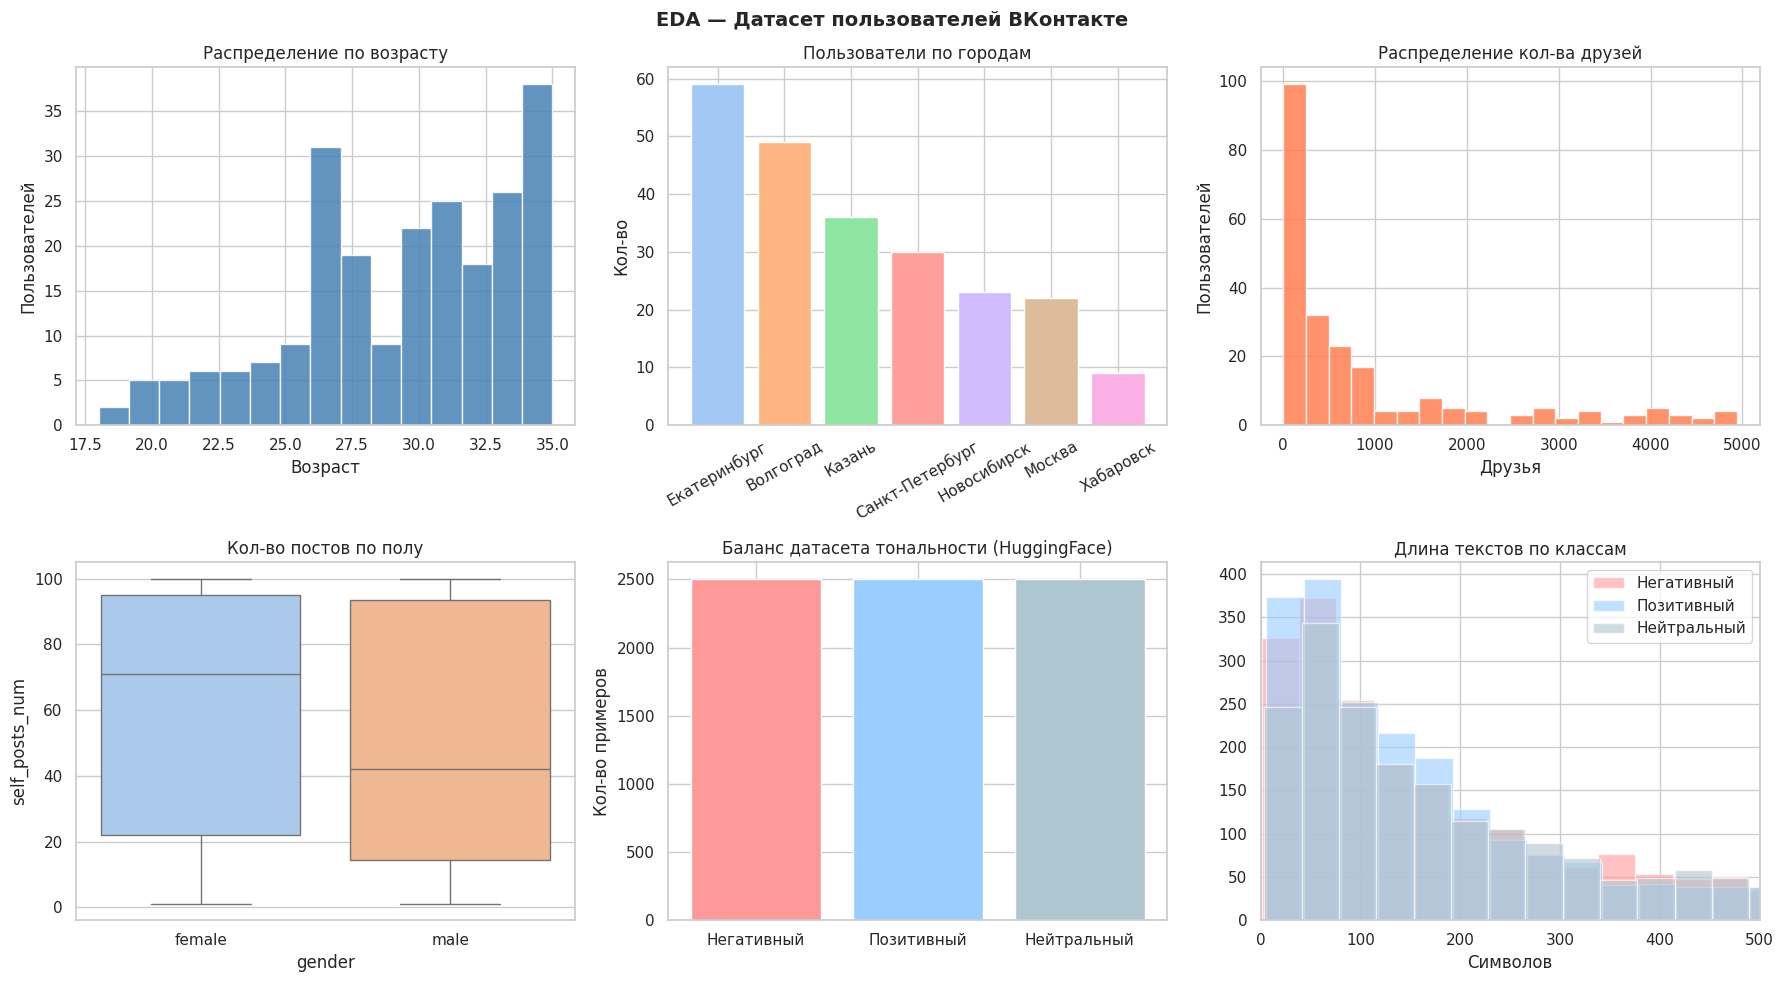

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('EDA — Датасет пользователей ВКонтакте', fontsize=14, fontweight='bold')
axes[0,0].hist(users_df['age'], bins=15, color='steelblue', edgecolor='white', alpha=0.85)
axes[0,0].set_title('Распределение по возрасту')
axes[0,0].set_xlabel('Возраст'); axes[0,0].set_ylabel('Пользователей')
city_counts = users_df['city'].value_counts()
axes[0,1].bar(city_counts.index, city_counts.values, color=sns.color_palette('pastel', len(city_counts)), edgecolor='white')
axes[0,1].set_title('Пользователи по городам')
axes[0,1].tick_params(axis='x', rotation=30); axes[0,1].set_ylabel('Кол-во')
axes[0,2].hist(users_df['friends_num'], bins=20, color='coral', edgecolor='white', alpha=0.85)
axes[0,2].set_title('Распределение кол-ва друзей')
axes[0,2].set_xlabel('Друзья'); axes[0,2].set_ylabel('Пользователей')
sns.boxplot(x='gender', y='self_posts_num', data=users_df, ax=axes[1,0], palette='pastel', hue='gender', legend=False)
axes[1,0].set_title('Кол-во постов по полу')
label_counts = df_sample['label'].value_counts().sort_index()
axes[1,1].bar(TARGET_NAMES, label_counts.values, color=['#ff9999', '#99ccff', '#aec6cf'], edgecolor='white')
axes[1,1].set_title('Баланс датасета тональности (HuggingFace)')
axes[1,1].set_ylabel('Кол-во примеров')
df_sample['text_len'] = df_sample['text'].str.len()
for label, color, name in zip([0,1,2], ['#ff9999','#99ccff','#aec6cf'], TARGET_NAMES):
    axes[1,2].hist(df_sample[df_sample['label']==label]['text_len'],
                   bins=40, alpha=0.6, color=color, label=name)
axes[1,2].set_title('Длина текстов по классам')
axes[1,2].set_xlabel('Символов'); axes[1,2].legend(); axes[1,2].set_xlim(0, 500)
plt.tight_layout()
plt.savefig('eda.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Предобработка текстов

Перед обучением ML-моделей выполняется очистка текстов: удаление URL, HTML-тегов, лишних пробелов. Это улучшает качество TF-IDF векторизации.

> **Примечание:** для RuBERT предобработка не требуется — трансформеры обрабатывают сырой текст, включая эмодзи и знаки препинания, на уровне сабворд-токенизатора.

In [31]:
def clean_text(text: str) -> str:
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'[^а-яёА-ЯЁa-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text.lower()
df_sample['text_clean'] = df_sample['text'].apply(clean_text)
print("Примеры очистки:")
for i in range(3):
    orig = df_sample['text'].iloc[i]
    clean = df_sample['text_clean'].iloc[i]
    print(f"Исходный: {orig[:100]}")
    print(f"Очищенный: {clean[:100]}")
    print()

Примеры очистки:
Исходный: Рассыпается на мелкие кусочки , когда в охлажденном , до 4 градусов, виде. не понравилось.
Очищенный: рассыпается на мелкие кусочки когда в охлажденном до 4 градусов виде не понравилось

Исходный: Были в данном заведении в середине апреля. В целом - неплохое место для завтрака на любой вкус. \n\n
Очищенный: были в данном заведении в середине апреля в целом неплохое место для завтрака на любой вкус n nчто п

Исходный: Заказала 11 сентября, пришли уже 25, цвет отличается от того что на фото
Очищенный: заказала 11 сентября пришли уже 25 цвет отличается от того что на фото



## 5. Baseline: TF-IDF + Logistic Regression (MVP)

Начинаем с простейшего подхода — это наш MVP.

**Обоснование выбора:**
- TF-IDF + Logistic Regression — стандартный baseline для текстовой классификации
- Быстро обучается, легко интерпретируем, не требует GPU
- Служит нижней границей для оценки более сложных методов

**Известные ограничения:**
- Не учитывает порядок слов и контекст
- Плохо справляется со сленгом, иронией, отрицанием
- Нейтральный класс труден — нет ярко выраженных ключевых слов

Train: 6000 | Test: 1500
TF-IDF матрица: (6000, 20000)

TF-IDF + Logistic Regression (MVP)
              precision    recall  f1-score   support

  Негативный       0.51      0.52      0.52       500
  Позитивный       0.72      0.70      0.71       500
 Нейтральный       0.62      0.63      0.63       500

    accuracy                           0.62      1500
   macro avg       0.62      0.62      0.62      1500
weighted avg       0.62      0.62      0.62      1500



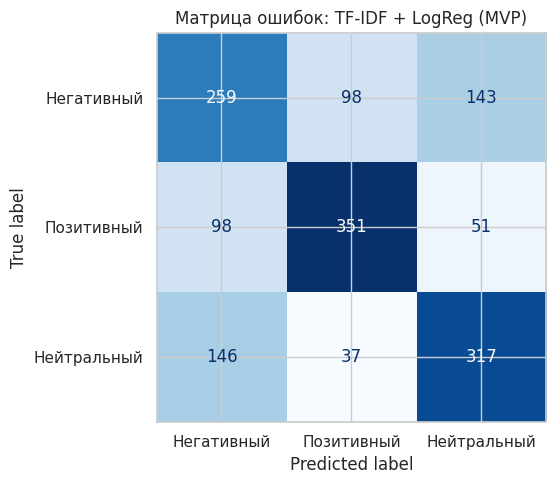

In [32]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df_sample['text'].tolist(),
    df_sample['label'].tolist(),
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df_sample['label'].tolist())
X_train_clean = [clean_text(t) for t in X_train_raw]
X_test_clean = [clean_text(t) for t in X_test_raw]
print(f"Train: {len(X_train_raw)} | Test: {len(X_test_raw)}")
vectorizer = TfidfVectorizer(max_features=20_000, ngram_range=(1, 2), sublinear_tf=True, min_df=3)
X_train_vec = vectorizer.fit_transform(X_train_clean)
X_test_vec = vectorizer.transform(X_test_clean)
print(f"TF-IDF матрица: {X_train_vec.shape}")
logreg = LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE, class_weight='balanced')
logreg.fit(X_train_vec, y_train)
logreg_preds = logreg.predict(X_test_vec)
logreg_f1 = f1_score(y_test, logreg_preds, average='weighted')
print("\nTF-IDF + Logistic Regression (MVP)")
print(classification_report(y_test, logreg_preds, target_names=TARGET_NAMES))
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, logreg_preds)
ConfusionMatrixDisplay(cm, display_labels=TARGET_NAMES).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Матрица ошибок: TF-IDF + LogReg (MVP)')
plt.tight_layout()
plt.savefig('cm_logreg.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. TF-IDF + LinearSVC

**Обоснование выбора LinearSVC:**
- На задачах с большим словарём LinearSVC теоретически конкурентоспособен с Logistic Regression
- Эффективно работает с разреженными матрицами (TF-IDF)
- Биграммы учитывают устойчивые словосочетания типа «не нравится», «очень хорошо»

### Кросс-валидация для обеих ML-моделей

Для получения устойчивых оценок применяется 5-кратная стратифицированная кросс-валидация.

TF-IDF + LinearSVC
              precision    recall  f1-score   support

  Негативный       0.50      0.50      0.50       500
  Позитивный       0.71      0.71      0.71       500
 Нейтральный       0.62      0.62      0.62       500

    accuracy                           0.61      1500
   macro avg       0.61      0.61      0.61      1500
weighted avg       0.61      0.61      0.61      1500



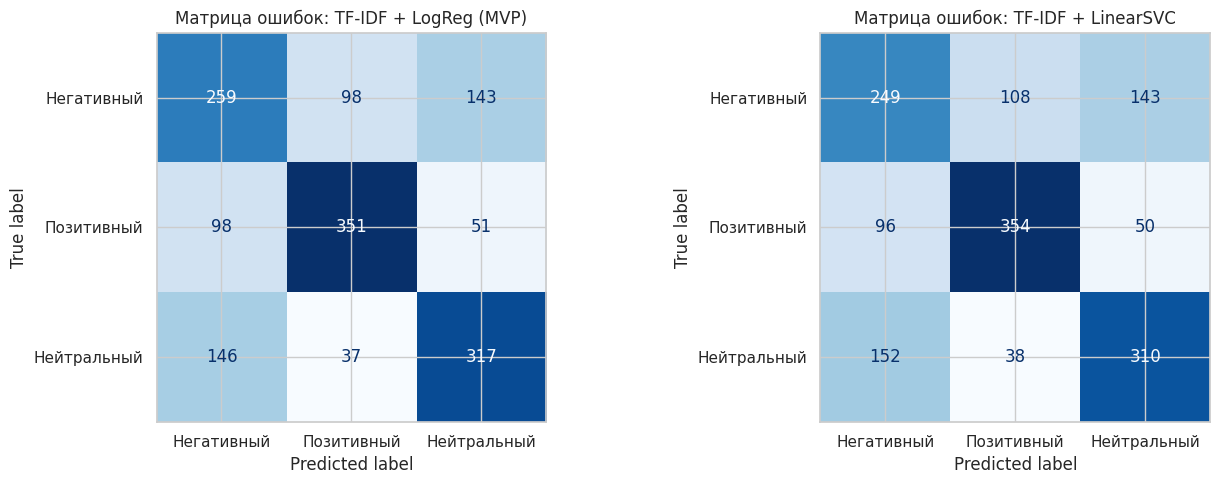

In [33]:
svc = LinearSVC(max_iter=2000, C=0.5, random_state=RANDOM_STATE, class_weight='balanced')
svc.fit(X_train_vec, y_train)
svc_preds = svc.predict(X_test_vec)
svc_f1 = f1_score(y_test, svc_preds, average='weighted')
print("TF-IDF + LinearSVC")
print(classification_report(y_test, svc_preds, target_names=TARGET_NAMES))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, preds, name in [(axes[0], logreg_preds, 'LogReg (MVP)'), (axes[1], svc_preds, 'LinearSVC')]:
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=TARGET_NAMES).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Матрица ошибок: TF-IDF + {name}')
plt.tight_layout()
plt.savefig('cm_ml.png', dpi=150, bbox_inches='tight')
plt.show()

In [34]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
X_all_clean = [clean_text(t) for t in df_sample['text'].tolist()]
X_all_vec = vectorizer.transform(X_all_clean)
y_all = df_sample['label'].tolist()
cv_logreg = cross_val_score(logreg, X_all_vec, y_all, cv=skf, scoring='f1_weighted', n_jobs=-1)
cv_svc    = cross_val_score(svc,    X_all_vec, y_all, cv=skf, scoring='f1_weighted', n_jobs=-1)
print("Результаты 5-кратной кросс-валидации (weighted F1):")
print(f"TF-IDF + LogReg:    {cv_logreg.mean():.4f} ± {cv_logreg.std():.4f}")
print(f"TF-IDF + LinearSVC: {cv_svc.mean():.4f} ± {cv_svc.std():.4f}")

Результаты 5-кратной кросс-валидации (weighted F1):
TF-IDF + LogReg:    0.6286 ± 0.0149
TF-IDF + LinearSVC: 0.6193 ± 0.0161


## 7. Deep Learning: RuBERT (zero-shot inference)

**Модель:** [`blanchefort/rubert-base-cased-sentiment`](https://huggingface.co/blanchefort/rubert-base-cased-sentiment)  
RuBERT — трансформер, предобученный на русскоязычных текстах и дообученный для задачи анализа тональности.

**Обоснование выбора:**
- Нативно трёхклассовая модель (POSITIVE / NEUTRAL / NEGATIVE) — соответствует постановке задачи
- Контекстные эмбеддинги: понимает морфологию русского языка, сленг, иронию, отрицание
- Предобучена на >1 млрд токенов — устойчива к малым данным и разнообразию стилей
- Архитектура BERT учитывает двусторонний контекст каждого слова

Без дообучения на нашем датасете.
TF-IDF-модели обучены на том же датасете (in-domain), RuBERT — нет.

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


RuBERT (Deep Learning, zero-shot)
              precision    recall  f1-score   support

  Негативный       0.27      0.31      0.29       500
  Позитивный       0.69      0.69      0.69       500
 Нейтральный       0.25      0.21      0.23       500

    accuracy                           0.41      1500
   macro avg       0.40      0.41      0.40      1500
weighted avg       0.40      0.41      0.40      1500



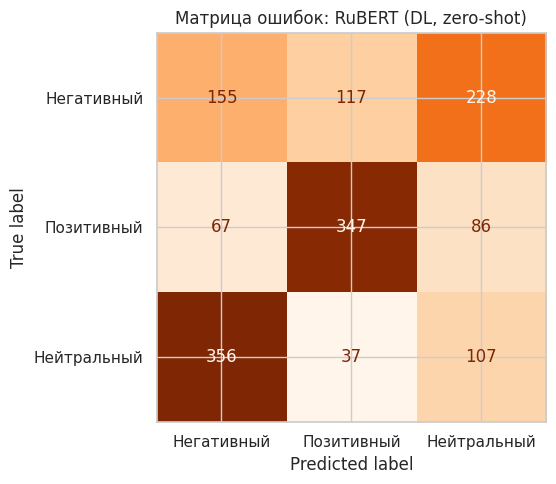

In [35]:
sentiment_pipe = hf_pipeline(
    "sentiment-analysis",
    model="blanchefort/rubert-base-cased-sentiment",
    device=DEVICE,
    truncation=True,
    max_length=512)
def rubert_label(r: dict) -> int:
    if r['label'] == 'POSITIVE': return 1
    elif r['label'] == 'NEGATIVE': return 0
    else: return 2
dl_preds_raw = sentiment_pipe(X_test_raw, batch_size=32)
dl_preds = [rubert_label(r) for r in dl_preds_raw]
dl_f1 = f1_score(y_test, dl_preds, average='weighted')
print("\nRuBERT (Deep Learning, zero-shot)")
print(classification_report(y_test, dl_preds, target_names=TARGET_NAMES))
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, dl_preds)
ConfusionMatrixDisplay(cm, display_labels=TARGET_NAMES).plot(ax=ax, colorbar=False, cmap='Oranges')
ax.set_title('Матрица ошибок: RuBERT (DL, zero-shot)')
plt.tight_layout()
plt.savefig('cm_dl.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Сравнение моделей: количественный и качественный анализ

### 8.1 Количественное сравнение

Итоговая таблица сравнения моделей:
                Модель           Тип  F1-weighted  Accuracy  CV F1 (mean)  CV F1 (±std)
 TF-IDF + LogReg (MVP)  Classical ML     0.618507  0.618000      0.628624      0.014858
    TF-IDF + LinearSVC  Classical ML     0.608548  0.608667      0.619337      0.016057
RuBERT (DL, zero-shot) Deep Learning     0.404411  0.406000           NaN           NaN


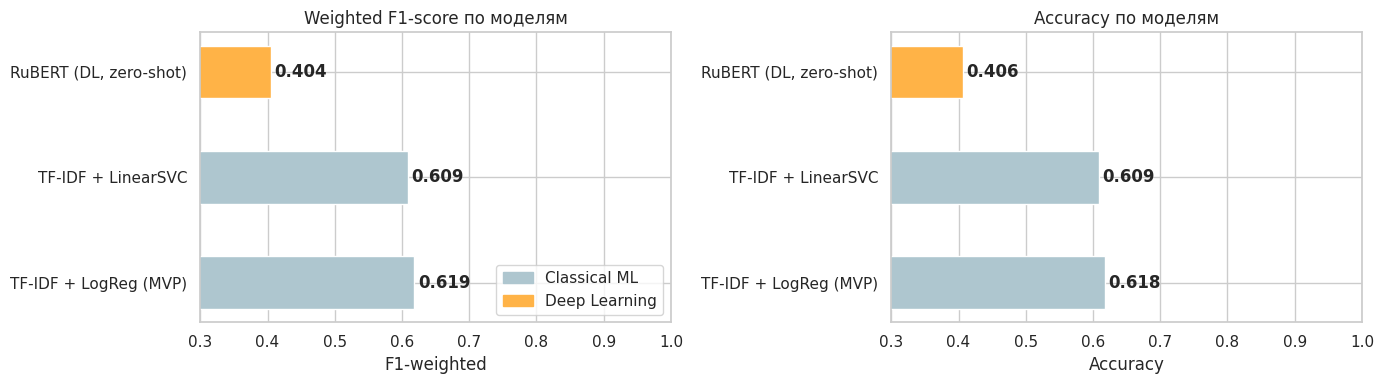

In [36]:
results_df = pd.DataFrame({
    'Модель': ['TF-IDF + LogReg (MVP)', 'TF-IDF + LinearSVC', 'RuBERT (DL, zero-shot)'],
    'Тип': ['Classical ML', 'Classical ML', 'Deep Learning'],
    'F1-weighted': [logreg_f1, svc_f1, dl_f1],
    'Accuracy': [accuracy_score(y_test, logreg_preds), accuracy_score(y_test, svc_preds), accuracy_score(y_test, dl_preds)],
    'CV F1 (mean)': [cv_logreg.mean(), cv_svc.mean(), float('nan')],
    'CV F1 (±std)': [cv_logreg.std(),  cv_svc.std(),  float('nan')]}).sort_values('F1-weighted', ascending=False).reset_index(drop=True)
print("Итоговая таблица сравнения моделей:")
print(results_df.to_string(index=False))
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
color_map = {'Classical ML': '#aec6cf', 'Deep Learning': '#ffb347'}
colors = [color_map[t] for t in results_df['Тип']]
for ax, col, title in [(axes[0], 'F1-weighted', 'Weighted F1-score по моделям'), (axes[1], 'Accuracy', 'Accuracy по моделям')]:
    bars = ax.barh(results_df['Модель'], results_df[col], color=colors, edgecolor='white', height=0.5)
    ax.set_xlim(0.3, 1.0); ax.set_xlabel(col); ax.set_title(title)
    for bar, val in zip(bars, results_df[col]):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontweight='bold')
legend_handles = [mpatches.Patch(color='#aec6cf', label='Classical ML'), mpatches.Patch(color='#ffb347', label='Deep Learning')]
axes[0].legend(handles=legend_handles, loc='lower right')
plt.tight_layout()
plt.savefig('ml_vs_dl.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.2 Качественный анализ — примеры разногласий моделей

На трудных примерах (ирония, сленг, разговорный стиль) заметны различия в поведении моделей. Все три модели одинаково не справляются с прямой иронией (примеры 1-2). RuBERT проявляет склонность к классификации неоднозначных текстов как негативный: в примерах 5 и 8 это соответствует скрытому тону, однако в примере 7 (Мама приехала!! Так рада её видеть) RuBERT ошибается — присваивает явно позитивному тексту класс Негативный. TF-IDF-модели ведут себя консервативнее, тяготея к Нейтральный на неоднозначных примерах.

In [37]:
hard_examples = [
    "Ну конечно, просто великолепно — всё как всегда сломалось в самый нужный момент.",
    "Отличный день, чего уж говорить. Три часа в пробке, потерял кошелёк и промок под дождём.",
    "Нормально съездил. Не умер.",
    "Уф, наконец-то пятница. Выжил ещё одну неделю как-то.",
    "Опять эти новости... всё хорошо, всё прекрасно, только жить немного грустно.",
    "Сдал экзамен. Четвёрка. Ладно.",
    "Мама приехала!! Так рада её видеть после стольких месяцев!",
    "Какой смысл вообще стараться, всё равно ничего не меняется."]
hard_vec = vectorizer.transform([clean_text(t) for t in hard_examples])
lr_preds = logreg.predict(hard_vec)
svc_preds_h = svc.predict(hard_vec)
dl_preds_h = [rubert_label(r) for r in sentiment_pipe(hard_examples)]
print("Качественное сравнение на трудных примерах:")
print(f"{'Текст':<59} {'LogReg':<14} {'SVC':<14} {'RuBERT':<14}")
for text, lp, sp, dp in zip(hard_examples, lr_preds, svc_preds_h, dl_preds_h):
    lr_name  = LABEL2NAME[lp]
    svc_name = LABEL2NAME[sp]
    dl_name  = LABEL2NAME[dp]
    print(f"{text[:55]:<70} {lr_name:<14} {svc_name:<14} {dl_name:<14}")

Качественное сравнение на трудных примерах:
Текст                                                       LogReg         SVC            RuBERT        
Ну конечно, просто великолепно — всё как всегда сломало                Позитивный     Позитивный     Позитивный    
Отличный день, чего уж говорить. Три часа в пробке, пот                Позитивный     Позитивный     Позитивный    
Нормально съездил. Не умер.                                            Нейтральный    Нейтральный    Негативный    
Уф, наконец-то пятница. Выжил ещё одну неделю как-то.                  Негативный     Негативный     Нейтральный   
Опять эти новости... всё хорошо, всё прекрасно, только                 Позитивный     Позитивный     Негативный    
Сдал экзамен. Четвёрка. Ладно.                                         Нейтральный    Нейтральный    Негативный    
Мама приехала!! Так рада её видеть после стольких месяц                Нейтральный    Нейтральный    Негативный    
Какой смысл вообще стараться, всё равно

### 8.3 Обоснование выбора модели для анализа постов ВКонтакте

По количественным метрикам на бенчмарке лучший результат показывает TF-IDF + Logistic Regression (Weighted F1 = 0.619), за ним TF-IDF + LinearSVC (F1 = 0.609). Сравнение проводилось на одинаковом тестовом разбиении; TF-IDF модели получали предобработанный текст, RuBERT — оригинальный, что соответствует архитектурным предположениям каждой модели

Для анализа постов ВКонтакте используется RuBERT:
1. Разные целевые домены: посты VK — неформальный разговорный текст с иронией и сленгом. Модель blanchefort/rubert-base-cased-sentiment обучалась на текстах социальных сетей — её целевой домен совпадает с VK, а не с бенчмарком из отзывов.
2. In-domain преимущество TF-IDF: TF-IDF тренировался на той же выборке k1tub, что создает искусственное преимущество. На VK-текстах без переобучения его качество не гарантировано.
3. Контекстные эмбеддинги: RuBERT учитывает контекст и порядок слов — важно для разговорных конструкций с имплицитным тоном.
4. Ограничение: без размеченных VK-постов прямое сравнение на целевом домене невозможно.

## 9. Применение RuBERT к постам ВКонтакте

Прогоняем все собранные посты пользователей через выбранную DL-модель.

In [38]:
tqdm.pandas()
vk_preds_raw = sentiment_pipe(posts_df['text'].tolist(), batch_size=32)
posts_df['sentiment'] = [rubert_label(r) for r in vk_preds_raw]
posts_df['sentiment_name'] = posts_df['sentiment'].map(LABEL2NAME)
posts_df['confidence'] = [r['score'] for r in vk_preds_raw]
sentiment_scores = posts_df.groupby('user_id')['sentiment'].apply(lambda x: (x == 1).mean()).reset_index().rename(columns={'sentiment': 'positive_posts_percent'})
users_df = users_df.merge(sentiment_scores, on='user_id', how='left')
users_df['positive_posts_percent'] = users_df['positive_posts_percent'].fillna(0.5)
label_dist = posts_df['sentiment_name'].value_counts()
print(f"\nРаспределение тональности {len(posts_df)} постов VK:")
print(label_dist.to_string())
print(f"\nСредняя доля позитивных постов на пользователя: {users_df['positive_posts_percent'].mean():.3f}")


Распределение тональности 7203 постов VK:
sentiment_name
Позитивный     3216
Нейтральный    2481
Негативный     1506

Средняя доля позитивных постов на пользователя: 0.426


## 10. Расчёт Индекса цифрового счастья

Применяем формулу:

$$\text{Happiness_Index} = 0.30 \cdot S_{\text{network}} + 0.20 \cdot S_{\text{activity}} + 0.50 \cdot S_{\text{sentiment}}$$

Штрафной коэффициент 0.85 применяется при наличии токсичных сообществ.

In [39]:
scaler_activity = MinMaxScaler()
scaler_friends  = MinMaxScaler()
users_df['total_activity'] = users_df['self_posts_num'] + users_df['reposts_num']
users_df['activity_norm'] = scaler_activity.fit_transform(users_df[['total_activity']])
users_df['friends_norm']  = scaler_friends.fit_transform(users_df[['friends_num']])
users_df['happiness_index'] = (users_df['friends_norm'] * 0.30 + users_df['activity_norm'] * 0.20 + users_df['positive_posts_percent'] * 0.50)
users_df['happiness_index'] = np.where( users_df['has_toxic_groups'], users_df['happiness_index'] * 0.85, users_df['happiness_index'])
users_df['happiness_index'] = users_df['happiness_index'].clip(0, 1).round(3)
def happiness_level(idx: float) -> str:
    if idx >= 0.65: return 'Высокий'
    elif idx >= 0.40: return 'Средний'
    else: return 'Низкий'
users_df['happiness_level'] = users_df['happiness_index'].apply(happiness_level)
print(f"Средний Happiness Index: {users_df['happiness_index'].mean():.3f}")
print(f"Медиана: {users_df['happiness_index'].median():.3f}")
print(f"Максимум: {users_df['happiness_index'].max():.3f}")
print(f"Минимум: {users_df['happiness_index'].min():.3f}")
print(f"\nРаспределение по уровням:")
print(users_df['happiness_level'].value_counts().to_string())
print("\nТоп-10 пользователей по Happiness Index:")
cols = ['user_id','city','age','gender','friends_num','positive_posts_percent','happiness_index','happiness_level']
print(users_df[cols].sort_values('happiness_index', ascending=False).head(10).to_string(index=False))

Средний Happiness Index: 0.358
Медиана: 0.379
Максимум: 0.795
Минимум: 0.002

Распределение по уровням:
happiness_level
Низкий     132
Средний     89
Высокий      7

Топ-10 пользователей по Happiness Index:
  user_id            city  age gender  friends_num  positive_posts_percent  happiness_index happiness_level
137761692    Екатеринбург   33 female         4703                0.619565            0.795         Высокий
144413406    Екатеринбург   35 female         3994                0.704545            0.795         Высокий
235267573 Санкт-Петербург   30   male         4531                0.581395            0.766         Высокий
 38068582          Москва   32 female         2754                0.677966            0.706         Высокий
 48315616       Волгоград   35 female         4074                0.725806            0.689         Высокий
  5448563          Казань   35 female         3413                0.794118            0.684         Высокий
 29154851    Екатеринбург   31   male

## 11. Сегментированный анализ и визуализация

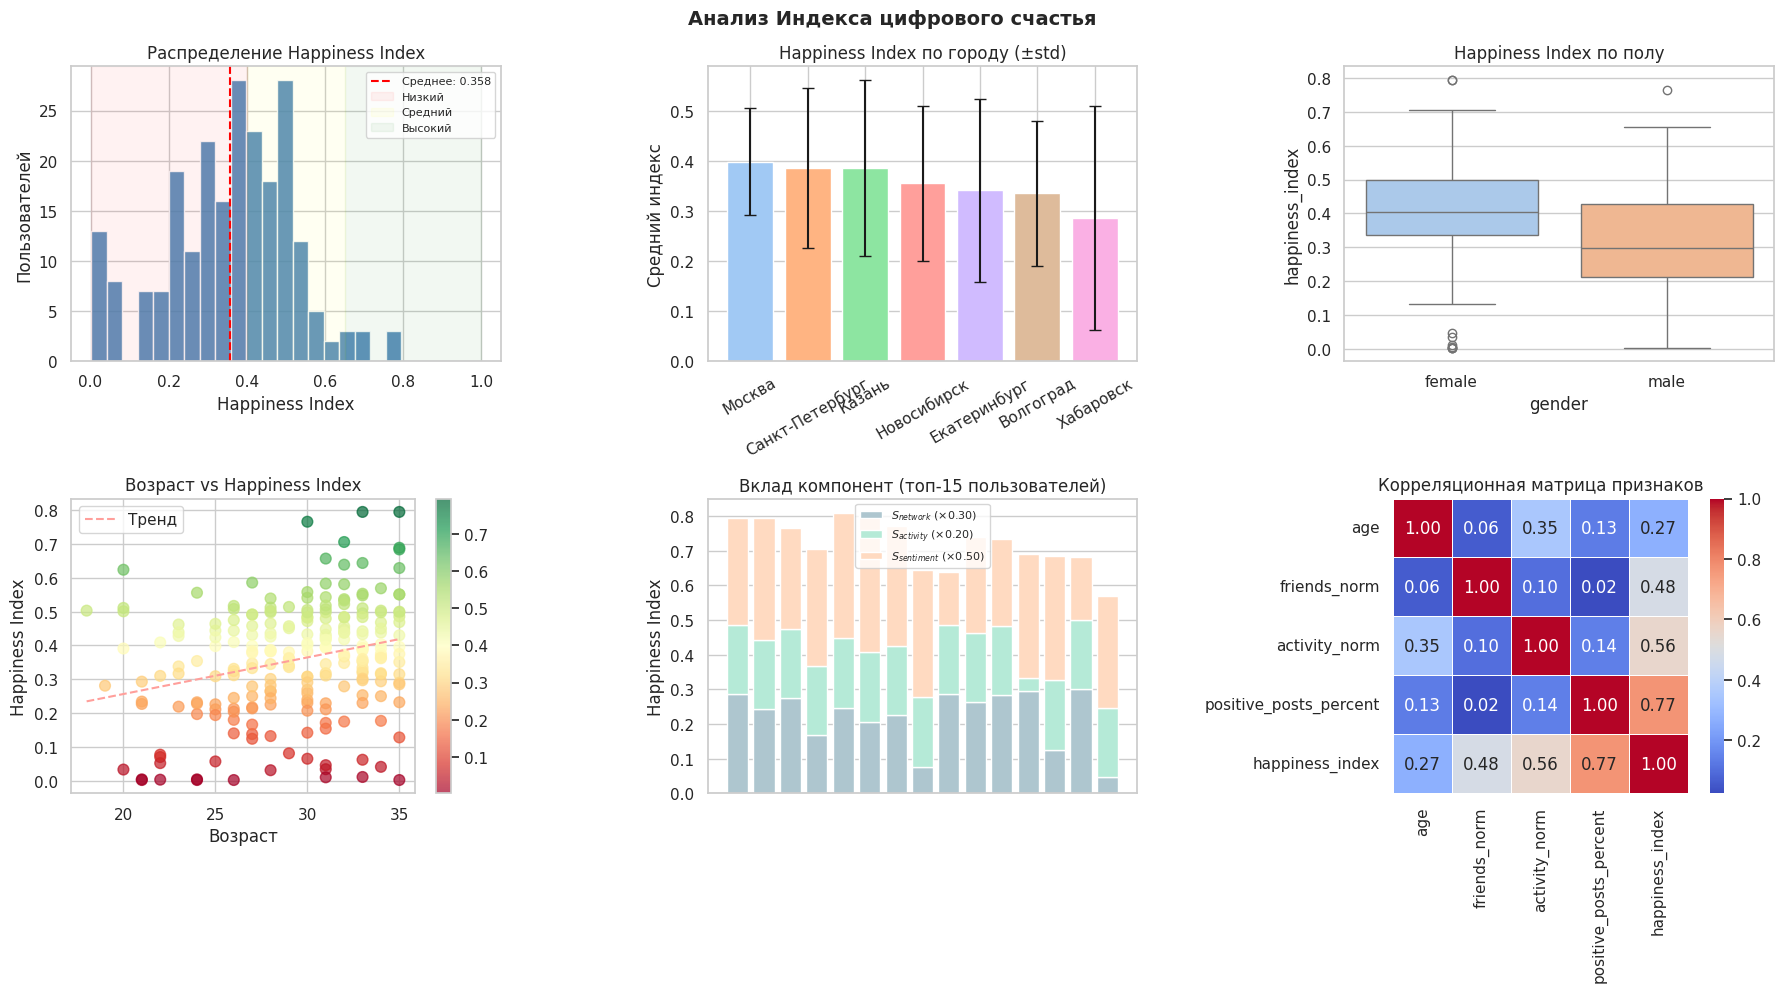

In [40]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Анализ Индекса цифрового счастья', fontsize=14, fontweight='bold')
mean_val = users_df['happiness_index'].mean()
axes[0,0].hist(users_df['happiness_index'], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
axes[0,0].axvline(mean_val, color='red', linestyle='--', label=f'Среднее: {mean_val:.3f}')
axes[0,0].axvspan(0, 0.40, alpha=0.05, color='red',   label='Низкий')
axes[0,0].axvspan(0.40, 0.65, alpha=0.05, color='yellow', label='Средний')
axes[0,0].axvspan(0.65, 1.0, alpha=0.05, color='green', label='Высокий')
axes[0,0].set_title('Распределение Happiness Index')
axes[0,0].set_xlabel('Happiness Index'); axes[0,0].set_ylabel('Пользователей')
axes[0,0].legend(fontsize=8)
city_stats = users_df.groupby('city')['happiness_index'].agg(['mean','std']).sort_values('mean', ascending=False)
axes[0,1].bar(city_stats.index, city_stats['mean'], yerr=city_stats['std'], capsize=4, color=sns.color_palette('pastel', len(city_stats)), edgecolor='white')
axes[0,1].set_title('Happiness Index по городу (±std)')
axes[0,1].tick_params(axis='x', rotation=30); axes[0,1].set_ylabel('Средний индекс')
sns.boxplot(x='gender', y='happiness_index', data=users_df, ax=axes[0,2], palette='pastel', hue='gender', legend=False)
axes[0,2].set_title('Happiness Index по полу')
sc = axes[1,0].scatter(users_df['age'], users_df['happiness_index'], c=users_df['happiness_index'], cmap='RdYlGn', alpha=0.7, s=60)
z = np.polyfit(users_df['age'], users_df['happiness_index'], 1)
x_line = np.array(sorted(users_df['age'].unique()))
axes[1,0].plot(x_line, np.poly1d(z)(x_line), 'r--', linewidth=1.5, label='Тренд')
axes[1,0].set_title('Возраст vs Happiness Index')
axes[1,0].set_xlabel('Возраст'); axes[1,0].set_ylabel('Happiness Index')
axes[1,0].legend()
plt.colorbar(sc, ax=axes[1,0])
top15 = users_df.nlargest(15, 'happiness_index')
x = range(len(top15))
axes[1,1].bar(x, top15['friends_norm'] * 0.30, label='$S_{network}$ (×0.30)', color='#aec6cf')
axes[1,1].bar(x, top15['activity_norm'] * 0.20, bottom=top15['friends_norm'] * 0.30, label='$S_{activity}$ (×0.20)', color='#b5ead7')
axes[1,1].bar(x, top15['positive_posts_percent'] * 0.50, bottom=top15['friends_norm']*0.30 + top15['activity_norm']*0.20, label='$S_{sentiment}$ (×0.50)', color='#ffdac1')
axes[1,1].set_title('Вклад компонент (топ-15 пользователей)')
axes[1,1].set_xticks([]); axes[1,1].legend(fontsize=8); axes[1,1].set_ylabel('Happiness Index')
corr_cols = ['age', 'friends_norm', 'activity_norm', 'positive_posts_percent', 'happiness_index']
corr = users_df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1,2], square=True, linewidths=0.5)
axes[1,2].set_title('Корреляционная матрица признаков')
plt.tight_layout()
plt.savefig('final_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [41]:
users_df.to_csv('happiness_report_final.csv', index=False, encoding='utf-8-sig')
print(f"Сохранено {len(users_df)} записей => happiness_report_final.csv")
print(f"Средний Happiness Index: {users_df['happiness_index'].mean():.3f}")
print(f"\nИтоговая сводка по уровням:")
level_stats = users_df.groupby('happiness_level')['happiness_index'].agg(['count','mean','std'])
print(level_stats.to_string())

Сохранено 228 записей => happiness_report_final.csv
Средний Happiness Index: 0.358

Итоговая сводка по уровням:
                 count      mean       std
happiness_level                           
Высокий              7  0.727429  0.056865
Низкий             132  0.251417  0.119041
Средний             89  0.487180  0.056699


## 12. Выводы и ограничения

### Сравнение моделей

| Модель | Тип | Weighted F1 | CV F1 (5-fold) | Примечание |
|--------|-----|-------------|----------------|------------|
| TF-IDF + LogReg | Classical ML (MVP) | 0.619 | 0.629 +/- 0.015 | Лучший на бенчмарке |
| TF-IDF + LinearSVC | Classical ML | 0.609 | 0.619 +/- 0.016 | Близок к LogReg |
| RuBERT (zero-shot) | Deep Learning | 0.404 | — | Значительно ниже на бенчмарке |

**Вывод по моделям:**

На бенчмарке k1tub/sentiment_dataset лучший результат показывает TF-IDF + Logistic Regression (F1 = 0.619, CV = 0.629 +/- 0.015). Обученные in-domain модели превосходят zero-shot трансформеры при совпадении доменов.

RuBERT (zero-shot, F1 = 0.404) уступает классическим моделям на бенчмарке. По классам: Позитивный F1 = 0.69 (хорошо), Нейтральный и Негативный F1 ~ 0.25-0.27 (плохо). Причина — доменное расхождение (бенчмарк — отзывы, RuBERT обучен на текстах соцсетях).

Для расчёта Happiness Index выбран RuBERT — его обучающий домен (соцсети) совпадает с VK-постами.

### Результаты расчёта Happiness Index

- Средний Happiness Index: 0.358, медиана — 0.379, макс. — 0.795, мин. — 0.002
- Распределение: Низкий — 132 профиля (57.9%), Средний — 89 (39.0%), Высокий — 7 (3.1%)
- Наибольший вклад: S_sentiment (вес 0.50) — тональность постов

### Ограничения

1. Эффект витрины: пользователи транслируют позитив, занижая реальный негативный фон
2. Малый объём выборки: 228 пользователей недостаточно для значимых демографических выводов
3. Отсутствие разметки VK-постов: качество на целевом домене не измерено напрямую
4. Цифровое не равно реальному: индекс отражает цифровое поведение, а не психологическое

### Практическое применение

Gradio-приложение на HuggingFace Spaces: https://huggingface.co/spaces/meowmeow262/digital-happiness
